# ALNS hyperparameter analysis


## Imports

In [1]:
import sys
import os

root = os.path.dirname(os.getcwd())
sys.path.append(root)

import time
import numpy as np
import matplotlib.pyplot as plt

from cvrptw.parser import parse_solomon
from cvrptw.heuristics.alns import solve


## Configuration

Note: the best known minimises vehicles first and then distance while my solve function
minimises only distance so the gap can
be negative ie shorter distance but more vehicles which is why we also record
the vehicle count


In [2]:
INSTANCES = {
    'c101': '../data/solomon/c101.txt',
    'r101': '../data/solomon/r101.txt',
    'rc101': '../data/solomon/rc101.txt',
    'r201': '../data/solomon/r201.txt',
    'rc201': '../data/solomon/rc201.txt',
}
BEST_KNOWN = {
    'c101': 828.94,
    'r101': 1650.80,
    'rc101': 1696.95,
    'r201': 1252.37,
    'rc201': 1406.94,
}

SEEDS = [0, 1, 2]


In [3]:
def gap_to_ref(distance, ref):
    if ref is None:
        return float('nan')
    return (distance - ref) / ref * 100


def run(name, instance, seeds, **params):
    ref = BEST_KNOWN.get(name)
    records = []
    for seed in seeds:
        start = time.perf_counter()
        best, stopped_at = solve(instance, seed=seed, **params)
        total_time = time.perf_counter() - start
        distance = best.distance()
        records.append({
            'instance': name,
            'seed': seed,
            'distance': distance,
            'vehicles': len(best.routes),
            'gap': gap_to_ref(distance, ref),
            'runtime': total_time,
            'stopped_at': stopped_at,
            **params,
        })
    return records

def plot_time_gap(records, param_key, title):
    values = sorted(set(r[param_key] for r in records))
    times = [np.nanmean([r['runtime'] for r in records if r[param_key] == v]) for v in values]
    gaps = [np.nanmean([r['gap'] for r in records if r[param_key] == v]) for v in values]

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(times, gaps, c=values, cmap='viridis', s=90)
    for t, g, v in zip(times, gaps, values):
        ax.annotate(str(v), (t, g), textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xlabel('mean runtime (s)')
    ax.set_ylabel('mean gap to optimum (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, label=param_key)
    plt.show()

In [4]:
def plot_gap_vs_value(records, param_key, values, title):
    # gap vs parameter value, one line per instance, mean +/- std over seeds
    fig, ax = plt.subplots(figsize=(8, 5))
    for name in INSTANCES:
        means = [np.nanmean([r['gap'] for r in records if r['instance'] == name and r[param_key] == v]) for v in values]
        stds = [np.nanstd([r['gap'] for r in records if r['instance'] == name and r[param_key] == v]) for v in values]
        ax.errorbar(values, means, yerr=stds, marker='o', capsize=3, label=name)
    ax.set_xlabel(param_key)
    ax.set_ylabel('mean gap to optimum (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


## Parameter tunning
### First one parametter at a time for a simple aproach to know good parameters and then a grid search to get the finnal parameters
- Destruction size



In [5]:
DESTRUCTION_SIZES = [5, 10, 15, 20, 30, 40]
ITERATIONS = 300

n_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for destruction_size in DESTRUCTION_SIZES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, n=destruction_size)
        n_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} n={destruction_size} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 n=5 gap_mean=19.773347573019493%  dist_mean=992.8491873717879  time_mean=0.6013619999866933s  stop_mean=287.3333333333333
c101 n=10 gap_mean=10.188663886982255%  dist_mean=913.3979104247506  time_mean=1.026158699998632s  stop_mean=274.0
c101 n=15 gap_mean=3.830875338296769%  dist_mean=860.6956580292773  time_mean=1.5932440332447488s  stop_mean=281.0
c101 n=20 gap_mean=4.304187199088305%  dist_mean=864.6191293681227  time_mean=1.911147200036794s  stop_mean=276.0
c101 n=30 gap_mean=-0.000377959462227171%  dist_mean=828.9368669428337  time_mean=3.3533670334145427s  stop_mean=299.0
c101 n=40 gap_mean=-0.0003779594622180279%  dist_mean=828.936866942834  time_mean=4.276553699979559s  stop_mean=206.66666666666666
r101 n=5 gap_mean=8.727802795169858%  dist_mean=1794.878568542664  time_mean=0.6404285333119333s  stop_mean=300.0
r101 n=10 gap_mean=3.9687105938585%  dist_mean=1716.3154744834162  time_mean=1.1663511667090158s  stop_mean=300.0
r101 n=15 gap_mean=2.356233287898283%  dist_mean=16

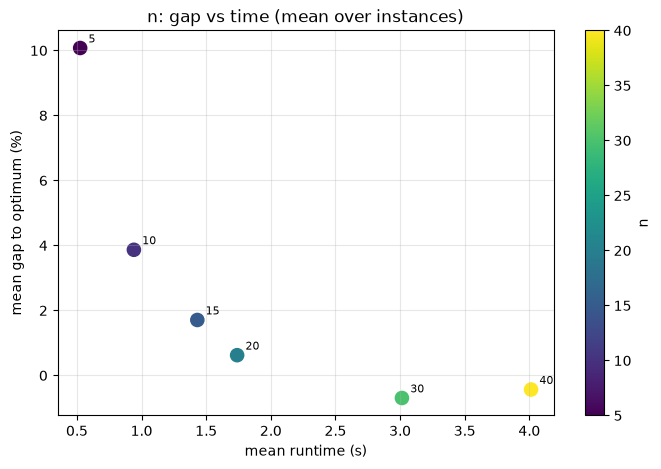

In [6]:
plot_time_gap(n_list, 'n', 'n: gap vs time (mean over instances)')


Probably look between 25-30

- coling (cooling rate)

In [7]:
COLING_VALUES = [0.99, 0.995, 0.999]
ITERATIONS = 300

coling_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for coling in COLING_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, coling=coling)
        coling_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} coling={coling} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 coling=0.99 gap_mean=2.668865895212712%  dist_mean=851.0632969517764  time_mean=1.712723566684872s  stop_mean=262.3333333333333
c101 coling=0.995 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=5.835387833261241s  stop_mean=278.6666666666667
c101 coling=0.999 gap_mean=1.210988986943117%  dist_mean=838.9783721083663  time_mean=2.459865066688508s  stop_mean=250.66666666666666
r101 coling=0.99 gap_mean=1.2543709828420793%  dist_mean=1671.507156184757  time_mean=2.1966960000184677s  stop_mean=258.3333333333333
r101 coling=0.995 gap_mean=2.04938877442663%  dist_mean=1684.6313098882347  time_mean=3.7127729000058025s  stop_mean=258.3333333333333
r101 coling=0.999 gap_mean=2.0111987570055785%  dist_mean=1684.000869080648  time_mean=2.2549219334032387s  stop_mean=256.0
rc101 coling=0.99 gap_mean=0.018151767447537104%  dist_mean=1697.258026417701  time_mean=3.7946772999906293s  stop_mean=297.3333333333333
rc101 coling=0.995 gap_mean=-0.915966806980051%  dist_mean=16

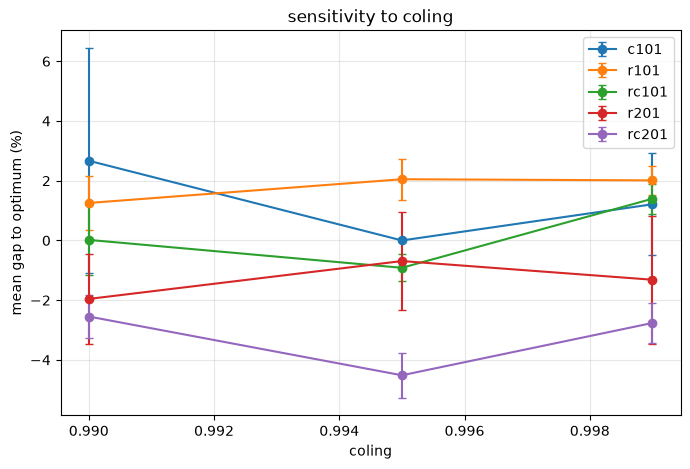

In [8]:
plot_gap_vs_value(coling_list, 'coling', COLING_VALUES, 'sensitivity to coling')


- t_factor (initial temperature)

In [9]:
T_FACTOR_VALUES = [0.01, 0.05, 0.1, 0.2]
ITERATIONS = 300

t_factor_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for t_factor in T_FACTOR_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, t_factor=t_factor)
        t_factor_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} t_factor={t_factor} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 t_factor=0.01 gap_mean=5.437142624975761%  dist_mean=874.0106500754741  time_mean=1.1541170999407768s  stop_mean=249.0
c101 t_factor=0.05 gap_mean=3.979265716706161%  dist_mean=861.9257252320641  time_mean=1.7911896666822333s  stop_mean=255.33333333333334
c101 t_factor=0.1 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=1.7835353000555187s  stop_mean=278.6666666666667
c101 t_factor=0.2 gap_mean=-0.000377959462227171%  dist_mean=828.936866942834  time_mean=1.3275987333618104s  stop_mean=300.0
r101 t_factor=0.01 gap_mean=0.48724897236458586%  dist_mean=1658.8435060357945  time_mean=1.725900666633s  stop_mean=300.0
r101 t_factor=0.05 gap_mean=1.1190643884052138%  dist_mean=1669.2735149237933  time_mean=1.3180799999584754s  stop_mean=246.33333333333334
r101 t_factor=0.1 gap_mean=2.04938877442663%  dist_mean=1684.6313098882347  time_mean=2.385676399959872s  stop_mean=258.3333333333333
r101 t_factor=0.2 gap_mean=2.2990276089455137%  dist_mean=1688.7523477684724 

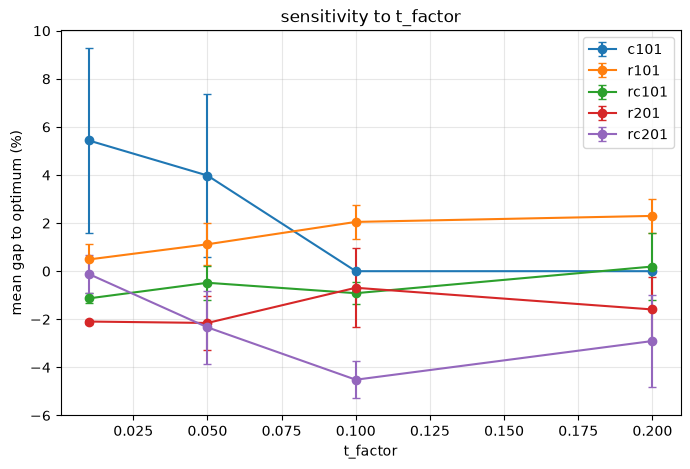

In [10]:
plot_gap_vs_value(t_factor_list, 't_factor', T_FACTOR_VALUES, 'sensitivity to t_factor')


- new_percentage (reaction factor)

In [11]:
NEW_PERCENTAGE_VALUES = [5, 15, 30, 50]
ITERATIONS = 300

new_percentage_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for new_percentage in NEW_PERCENTAGE_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, new_percentage=new_percentage)
        new_percentage_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} new_percentage={new_percentage} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 new_percentage=5 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=1.8101606999213498s  stop_mean=278.6666666666667
c101 new_percentage=15 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=1.8803547667339444s  stop_mean=278.6666666666667
c101 new_percentage=30 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=1.606938466584931s  stop_mean=278.6666666666667
c101 new_percentage=50 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=1.507522133256619s  stop_mean=278.6666666666667
r101 new_percentage=5 gap_mean=1.735438986377633%  dist_mean=1679.4486267871218  time_mean=1.627295933275794s  stop_mean=257.0
r101 new_percentage=15 gap_mean=2.04938877442663%  dist_mean=1684.6313098882347  time_mean=1.8223402000342805s  stop_mean=258.3333333333333
r101 new_percentage=30 gap_mean=2.0188897351794792%  dist_mean=1684.127831748343  time_mean=1.440423233434558s  stop_mean=258.3333333333333
r101 new_percent

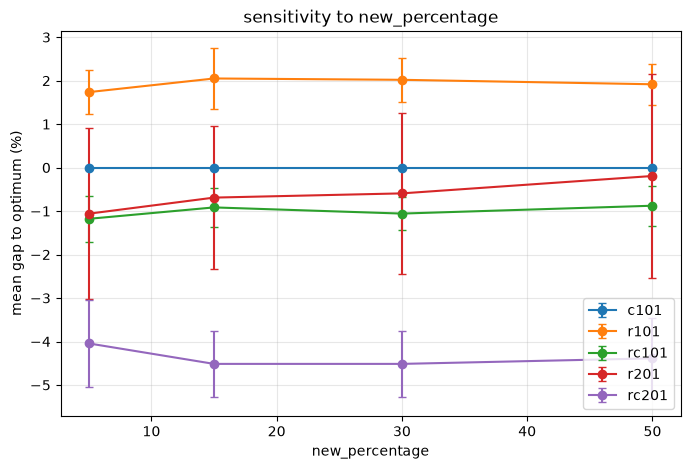

In [12]:
plot_gap_vs_value(new_percentage_list, 'new_percentage', NEW_PERCENTAGE_VALUES, 'sensitivity to new_percentage')


- iterations_update

In [13]:
ITERATIONS_UPDATE_VALUES = [50, 100, 200]
ITERATIONS = 300

iterations_update_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for iterations_update in ITERATIONS_UPDATE_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, iterations_update=iterations_update)
        iterations_update_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} iterations_update={iterations_update} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 iterations_update=50 gap_mean=-0.00037795946220888464%  dist_mean=828.9368669428341  time_mean=1.7016010999990006s  stop_mean=278.6666666666667
c101 iterations_update=100 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=1.2867472333988796s  stop_mean=278.6666666666667
c101 iterations_update=200 gap_mean=1.2109889869431172%  dist_mean=838.9783721083663  time_mean=1.4822280666946124s  stop_mean=278.6666666666667
r101 iterations_update=50 gap_mean=2.610413257311326%  dist_mean=1693.8927020516956  time_mean=1.4782092665943007s  stop_mean=249.33333333333334
r101 iterations_update=100 gap_mean=2.04938877442663%  dist_mean=1684.6313098882347  time_mean=1.0606871334215004s  stop_mean=258.3333333333333
r101 iterations_update=200 gap_mean=2.078652411615939%  dist_mean=1685.114394010956  time_mean=1.3042623333167285s  stop_mean=257.0
rc101 iterations_update=50 gap_mean=-0.2773849754649694%  dist_mean=1692.242915658847  time_mean=1.309359766698132s  stop_mean=287.66666

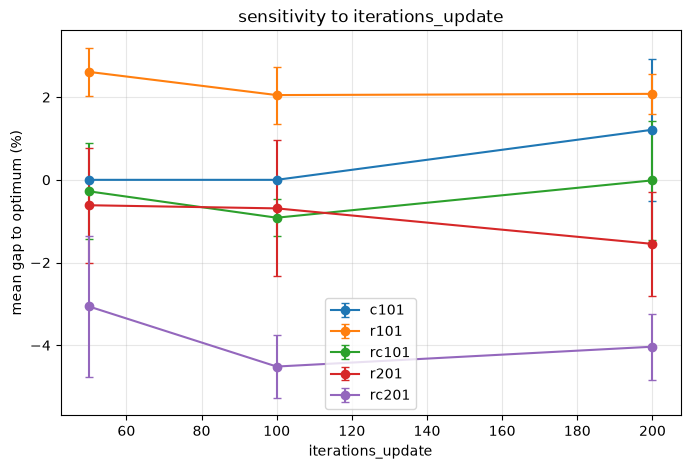

In [14]:
plot_gap_vs_value(iterations_update_list, 'iterations_update', ITERATIONS_UPDATE_VALUES, 'sensitivity to iterations_update')


## Grid search

Only around n and t_factor since are the ones that showed bigger difference, tunning this parameters would probably overfit more then actually help

In [15]:
N_GRID = [20, 22, 25, 27, 30]
T_FACTOR_GRID = [0.05, 0.1, 0.15]
SEEDS = [0, 1, 2, 3, 4]

grid_results = []
for n_val in N_GRID:
    for tf in T_FACTOR_GRID:
        gaps, times = [], []
        for name, path in INSTANCES.items():
            instance = parse_solomon(path)
            recs = run(name, instance, SEEDS, iterations=300, n=n_val, t_factor=tf)
            gaps += [r['gap'] for r in recs]
            times += [r['runtime'] for r in recs]
        grid_results.append((n_val, tf, np.nanmean(gaps), np.mean(times)))
        print(f'n={n_val:>2} t_factor={tf} mean_gap={np.nanmean(gaps):6.2f}%  mean_time={np.mean(times):.1f}s')

best = min(grid_results, key=lambda r: r[2])
print(f'\nbest mean gap: n={best[0]} t_factor={best[1]} -> {best[2]:.2f}% in {best[3]:.1f}s')


n=20 t_factor=0.05 mean_gap=  1.36%  mean_time=1.3s
n=20 t_factor=0.1 mean_gap=  0.86%  mean_time=1.3s
n=20 t_factor=0.15 mean_gap=  0.24%  mean_time=1.2s
n=22 t_factor=0.05 mean_gap= -0.04%  mean_time=1.3s
n=22 t_factor=0.1 mean_gap=  0.61%  mean_time=1.3s
n=22 t_factor=0.15 mean_gap=  0.49%  mean_time=1.4s
n=25 t_factor=0.05 mean_gap= -0.10%  mean_time=1.5s
n=25 t_factor=0.1 mean_gap= -0.26%  mean_time=1.4s
n=25 t_factor=0.15 mean_gap= -0.18%  mean_time=1.5s
n=27 t_factor=0.05 mean_gap= -0.20%  mean_time=1.7s
n=27 t_factor=0.1 mean_gap= -0.31%  mean_time=1.7s
n=27 t_factor=0.15 mean_gap=  0.12%  mean_time=1.7s
n=30 t_factor=0.05 mean_gap= -0.20%  mean_time=1.8s
n=30 t_factor=0.1 mean_gap= -0.75%  mean_time=1.8s
n=30 t_factor=0.15 mean_gap= -0.49%  mean_time=2.0s

best mean gap: n=30 t_factor=0.1 -> -0.75% in 1.8s
